# Global Ocean MultiScale MeshGraph

In this notebook different meshes for the data-driven model under development are explored. The first is the icosahedral multi-mesh used by GraphCast as is, the second is a masked version of the previous, finally, a hierarchical triangle mesh obtained with `seamsh` has been considered.

In [1]:
# 1. plot the criteria in mesh_size_maps.nc
# 2. plot the mesh size based on distance from coast

In [2]:
import tempfile
import zipfile
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import seamsh.geometry
import xarray
from geopy.geocoders import Nominatim
from osgeo import osr
from seamsh.geometry import CurveType

from graphcast import mesh_connectivity
from graphcast import mesh_graph
from graphcast import ocean_mesh
from graphcast import plot_utils

In [3]:
save_figures = True
save_mesh = True

output_dir = Path('outputs/multiscale_meshgraph')
if not output_dir.exists():
  output_dir.mkdir(parents=True)

In [4]:
# The zoom-ins will be around the following area.
geolocator = Nominatim(user_agent="multiscale_meshgraph")
location = geolocator.geocode("Bryant University")
width, height = 65.0, 20.0
bounds = [location.longitude - width / 2, location.longitude + width / 2,
          location.latitude - height / 2, location.latitude + height / 2]

## Cartesian Grids

In [5]:
seamask_lores = xarray.open_zarr('data/dataset/glorys12_bathymetry_tres-static_res-1.0_levels-1.zip')
mask_lores = seamask_lores.mask
mask_lores = mask_lores.criterion()
mask_lores = mask_lores.rename(latitude="lat", longitude="lon")

grid_lon_lores, grid_lat_lores = np.meshgrid(mask_lores.lon, mask_lores.lat)
masked_grid_lon_lores = grid_lon_lores[mask_lores.astype(bool)]
masked_grid_lat_lores = grid_lat_lores[mask_lores.astype(bool)]

mask_lores

<xarray.DataArray 'mask' (lat: 181, lon: 360)> Size: 65kB
array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]], shape=(181, 360), dtype=int8)
Coordinates:
  * lat      (lat) float32 724B -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon      (lon) float32 1kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
Attributes:
    long_name:      Land-sea mask: 1 = sea ; 0 = land
    standard_name:  sea_binary_mask
    units:          1

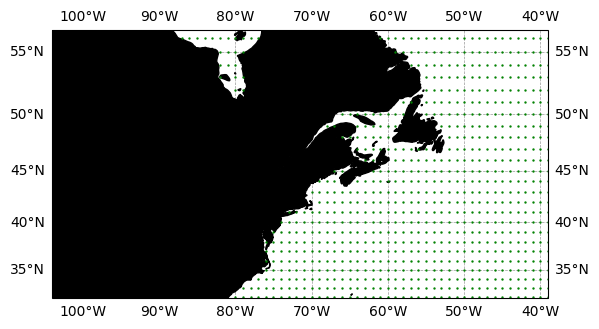

In [6]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mercator())
ax.set_extent(bounds)
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '50m', edgecolor='face', facecolor='black'))
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.4, color='k', linestyle='--')

ax.scatter(masked_grid_lon_lores, masked_grid_lat_lores, marker='.', color="green", s=2.0, zorder=2, transform=ccrs.PlateCarree())

if save_figures:
  plt.savefig(output_dir / 'grid_res-1.0_zoomin.png', bbox_inches='tight')


In [7]:
seamask_hires = xarray.open_zarr('data/dataset/glorys12_bathymetry_tres-static_res-0.5_levels-1.zip')
mask_hires = seamask_hires.mask
mask_hires = mask_hires.criterion()
mask_hires = mask_hires.rename(latitude="lat", longitude="lon")


grid_lon_hires, grid_lat_hires = np.meshgrid(mask_hires.lon, mask_hires.lat)
masked_grid_lon_hires = grid_lon_hires[mask_hires.astype(bool)]
masked_grid_lat_hires = grid_lat_hires[mask_hires.astype(bool)]

mask_hires

<xarray.DataArray 'mask' (lat: 361, lon: 720)> Size: 260kB
array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]], shape=(361, 720), dtype=int8)
Coordinates:
  * lat      (lat) float32 1kB -90.0 -89.5 -89.0 -88.5 ... 88.5 89.0 89.5 90.0
  * lon      (lon) float32 3kB 0.0 0.5 1.0 1.5 2.0 ... 358.0 358.5 359.0 359.5
Attributes:
    long_name:      Land-sea mask: 1 = sea ; 0 = land
    standard_name:  sea_binary_mask
    units:          1

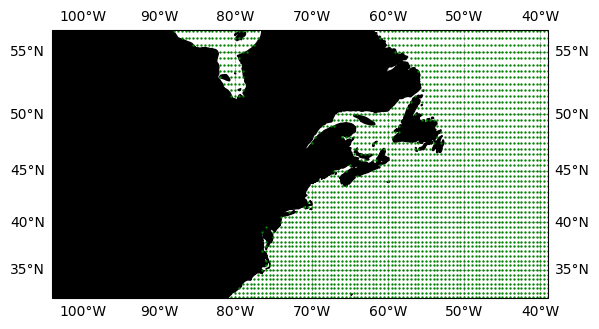

In [8]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mercator())
ax.set_extent(bounds)
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '50m', edgecolor='face', facecolor='black'))
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.4, color='k', linestyle='--')

ax.scatter(masked_grid_lon_hires, masked_grid_lat_hires, marker='.', color="green", s=2.0, zorder=2, transform=ccrs.PlateCarree())

if save_figures:
  plt.savefig(output_dir / 'grid_res-0.5_zoomin.png', bbox_inches='tight')


## Hierarchical Triangle Mesh

In [9]:
with tempfile.TemporaryDirectory() as tmpdir:
  with zipfile.ZipFile("../data/ne_10m_coastline.zip") as archive:
    archive.extractall(tmpdir)
  osr.UseExceptions()
  domain_srs = osr.SpatialReference()
  domain_srs.ImportFromProj4("+ellps=WGS84 +proj=stere +lat_0=90")
  domain = seamsh.geometry.Domain(domain_srs)
  domain.add_boundary_curves_shp(tmpdir + "/ne_10m_coastline.shp", "featurecla", CurveType.POLYLINE)

 * Import features from "/var/folders/h1/290b3rbx6zggs9r8ygfgzcjw0000gn/T/tmpug7yylan/ne_10m_coastline.shp" * 
4132 features imported


In [10]:
# seamsh usage example taken from: https://jlambrechts.git-page.immc.ucl.ac.be/seamsh/examples/6-stereographics.html

SAMPLING = 10_000.0
EARTH_RADIUS = 6371008.7714

cart_srs = osr.SpatialReference("+ellps=WGS84 +proj=cart +units=m +x_0=0 +y_0=0")

dist_coast = seamsh.field.Distance(domain, SAMPLING, projection=cart_srs)

def mesh_size(distance_offset=20_000.0, min_size=20_000.0, max_size=200_000.0):

  def _mesh_size(x, projection):
    s_coast = np.clip(0.5 * (dist_coast(x, projection) - distance_offset), min_size, max_size)
    R_squared = EARTH_RADIUS ** 2
    x_squared = x ** 2
    stereo_factor = 2 / (1 + x_squared[:, 0] / R_squared + x_squared[:, 1] / R_squared)
    return s_coast / stereo_factor

  return _mesh_size

 * Create distance field * 
Sampling features for distance computation
4133 features sampled
Build KDTree with 157670 points


In [11]:
def uniform_mesh_size(value=100_000.0):

  def _mesh_size(x, projection):
    s_coast = np.full(x.shape[0], value)
    R_squared = EARTH_RADIUS ** 2
    x_squared = x ** 2
    stereo_factor = 2 / (1 + x_squared[:, 0] / R_squared + x_squared[:, 1] / R_squared)
    return s_coast / stereo_factor

  return _mesh_size

In [12]:
# ds = xarray.open_dataset('../data/mesh_size_maps.nc', engine='h5netcdf')
# for (_, var) in ds.data_vars.items():
#   plot_utils.mesh_size_plot(var, normalize=True)
#   plt.show()

In [13]:
COARSE_DOMAIN_MIN_SIZE = 20_000.0
COARSE_DOMAIN_MAX_SIZE = 200_000.0

coarse_domain = seamsh.geometry.coarsen_boundaries(domain, (0, 0), domain_srs, mesh_size(min_size=COARSE_DOMAIN_MIN_SIZE, max_size=COARSE_DOMAIN_MAX_SIZE))

 * Coarsen boundaries * 
Sampling curves for coarsening
4133 curves sampled
Delaunay mesh of sampled points
Extract boundaries


In [14]:
om = ocean_mesh_utils.get_ocean_mesh(domain=coarse_domain, mesh_size=uniform_mesh_size,  save_mesh=output_dir / 'test.msh')

 * Generate mesh * 
Build topology
Build gmsh model
Build mesh size field
Mesh with gmsh
Write "/var/folders/h1/290b3rbx6zggs9r8ygfgzcjw0000gn/T/tmplmby1_rv/natural_earth.msh" (msh version 4.1)


In [15]:
coarse_ocean_mesh = ocean_mesh_utils.get_ocean_mesh(domain=coarse_domain,
                                                    mesh_size=mesh_size,
                                                    save_mesh=(output_dir / 'coarse.msh') if save_mesh else None,
                                                    min_size=200_000.0,
                                                    max_size=800_000.0)
coarse_ocean_mesh_graph = mesh_graph.mesh_to_wgs(coarse_ocean_mesh)

 * Generate mesh * 
Build topology
Build gmsh model
Build mesh size field
Mesh with gmsh
Write "/var/folders/h1/290b3rbx6zggs9r8ygfgzcjw0000gn/T/tmp1lcpaoku/natural_earth.msh" (msh version 4.1)


In [16]:
fine_ocean_mesh = ocean_mesh_utils.get_ocean_mesh(domain=coarse_domain,
                                                  mesh_size=mesh_size,
                                                  save_mesh=(output_dir / 'fine.msh') if save_mesh else None,
                                                  min_size=100_000.0,
                                                  max_size=200_000.0)
fine_ocean_mesh_graph = mesh_graph.mesh_to_wgs(fine_ocean_mesh)

 * Generate mesh * 
Build topology
Build gmsh model
Build mesh size field
Mesh with gmsh
Write "/var/folders/h1/290b3rbx6zggs9r8ygfgzcjw0000gn/T/tmphs7g19ns/natural_earth.msh" (msh version 4.1)


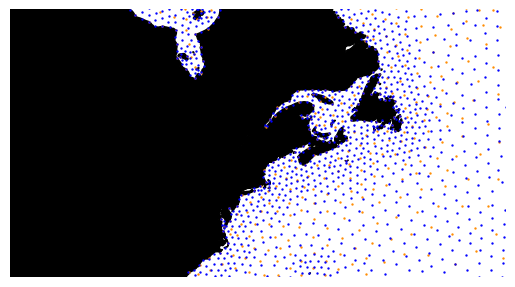

In [17]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mercator())
ax.set_extent(bounds)
ax.axis('off')
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '50m', edgecolor='face', facecolor='black'))

latitudes, longitudes = coarse_ocean_mesh_graph.vertices
ax.scatter(longitudes, latitudes, marker='.', color="darkorange", s=2.0, zorder=2, transform=ccrs.PlateCarree())

latitudes, longitudes = fine_ocean_mesh_graph.vertices
ax.scatter(longitudes, latitudes, marker='.', color="blue", s=2.0, zorder=2, transform=ccrs.PlateCarree())

if save_figures:
  plt.savefig(output_dir / 'latent_representation.png', bbox_inches='tight')

In [18]:
mesh_graph.graph_summary(mesh_graph.wgs_to_nx(coarse_ocean_mesh_graph))

'Nodes: 9337, Edges: 25143, Average degree: 5.385669915390382'

In [19]:
mesh_graph.graph_summary(mesh_graph.wgs_to_nx(fine_ocean_mesh_graph))

'Nodes: 25690, Edges: 72174, Average degree: 5.618840015570261'

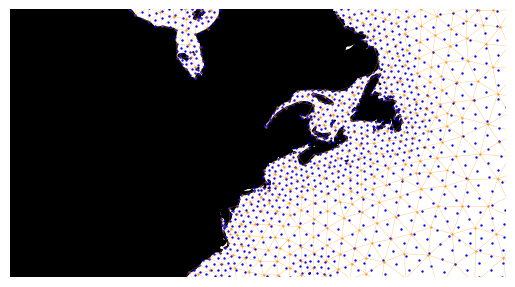

In [20]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mercator())
ax.set_extent(bounds)
ax.axis('off')
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '50m', edgecolor='face', facecolor='black'))

# Add coarse mesh vertices
latitudes, longitudes = coarse_ocean_mesh_graph.vertices
ax.scatter(longitudes, latitudes, marker='.', color="darkorange", s=1.0, zorder=2, transform=ccrs.PlateCarree())

# Add fine mesh vertices
latitudes, longitudes = fine_ocean_mesh_graph.vertices
ax.scatter(longitudes, latitudes, marker='.', color="blue", s=2.0, zorder=2, transform=ccrs.PlateCarree())

# Add coarse mesh edges
lc = plot_utils.get_line_collection(coarse_ocean_mesh_graph, linewidths=0.16, colors="darkorange", transform=ccrs.Geodetic())
ax.add_collection(lc)

if save_figures:
  plt.savefig(output_dir / 'coarse_meshgraph.png', bbox_inches='tight')


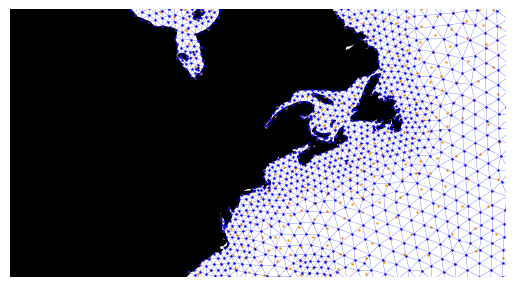

In [21]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mercator())
ax.set_extent(bounds)
ax.axis('off')
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '50m', edgecolor='face', facecolor='black'))

# Add coarse mesh vertices
latitudes, longitudes = coarse_ocean_mesh_graph.vertices
ax.scatter(longitudes, latitudes, marker='.', color="darkorange", s=2.0, zorder=2, transform=ccrs.PlateCarree())

# Add fine mesh vertices
latitudes, longitudes = fine_ocean_mesh_graph.vertices
ax.scatter(longitudes, latitudes, marker='.', color="blue", s=2.0, zorder=2, transform=ccrs.PlateCarree())

# Add fine mesh edges
lc = plot_utils.get_line_collection(fine_ocean_mesh_graph, linewidths=0.16, colors="blue", transform=ccrs.Geodetic())
ax.add_collection(lc)

if save_figures:
    plt.savefig(output_dir / 'fine_meshgraph.png', bbox_inches='tight')

In [22]:
dummy_multiscale_typed_graph = mesh_connectivity.get_dummy_xscaling_graph(coarse_ocean_mesh, fine_ocean_mesh)

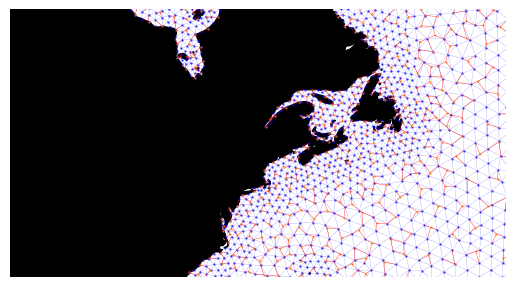

In [23]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mercator())

# Choose opensea box to show downsampling
# ax.set_extent([-30.0, -10.0, -5.0, 5.0])
ax.set_extent(bounds)
ax.axis('off')
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '50m', edgecolor='face', facecolor='black'))

# Add fine mesh vertices
latitudes, longitudes = fine_ocean_mesh_graph.vertices
ax.scatter(longitudes, latitudes, marker='.', color="blue", alpha=0.6, s=2.0, zorder=2, transform=ccrs.PlateCarree())

# Add fine mesh edges with alpha
lc = plot_utils.get_line_collection(fine_ocean_mesh_graph, linewidths=0.16, colors="blue", alpha=0.6, transform=ccrs.Geodetic())
ax.add_collection(lc)

# Add coarse mesh vertices
latitudes, longitudes = coarse_ocean_mesh_graph.vertices
ax.scatter(longitudes, latitudes, marker='.', color="darkorange", alpha=0.6, s=2.0, zorder=2, transform=ccrs.PlateCarree())

# Add downsampling ("fine2coarse") edges
downsampling_wgs_graph = mesh_graph.typed_to_wgs(dummy_multiscale_typed_graph, edge_set_name="fine2coarse")
lc = plot_utils.get_line_collection(downsampling_wgs_graph, linewidths=0.25, colors="red", transform=ccrs.Geodetic())
ax.add_collection(lc)

if save_figures:
  plt.savefig(output_dir / 'downsample.png', bbox_inches='tight')


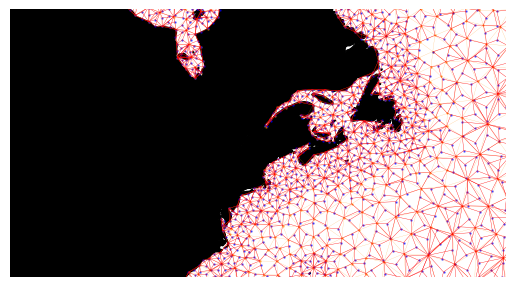

In [24]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mercator())

# Choose opensea box to show downsampling
# ax.set_extent([-30.0, -10.0, -5.0, 5.0])
ax.set_extent(bounds)
ax.axis('off')
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '50m', edgecolor='face', facecolor='black'))

# Add coarse mesh vertices
lc = plot_utils.get_line_collection(coarse_ocean_mesh_graph, linewidths=0.16, colors="darkorange", alpha=0.6, transform=ccrs.Geodetic())
ax.add_collection(lc)

# Add coarse mesh edges with alpha
latitudes, longitudes = coarse_ocean_mesh_graph.vertices
ax.scatter(longitudes, latitudes, marker='.', color="darkorange", alpha=0.6, s=2.0, zorder=2, transform=ccrs.PlateCarree())

# Plot fine mesh vertices
latitudes, longitudes = fine_ocean_mesh_graph.vertices
ax.scatter(longitudes, latitudes, marker='.', color="blue", alpha=0.6, s=2.0, zorder=2, transform=ccrs.PlateCarree())

# Add downsampling ("fine2coarse") edges
downsampling_wgs_graph = mesh_graph.typed_to_wgs(dummy_multiscale_typed_graph, edge_set_name="coarse2fine")
lc = plot_utils.get_line_collection(downsampling_wgs_graph, linewidths=0.25, colors="red", transform=ccrs.Geodetic())
ax.add_collection(lc)

if save_figures:
  plt.savefig(output_dir / 'upsample.png', bbox_inches='tight')


In [25]:
dummy_multiscale_typed_graph

TypedGraph(context=Context(n_graph=array([1]), features=()), nodes={'coarse_mesh_nodes': NodeSet(n_node=9337, features=array([[-1359002.85168619,   255042.27101819, -6205575.22678211],
       [-1199401.41850869,  -358087.88220202, -6233137.0900079 ],
       [  446518.32616068,  -925380.65820913, -6273727.70502842],
       ...,
       [-6309606.69339926,  -215583.87243757,  -904162.02107254],
       [-2843810.36220855, -2911564.35712164, -4894356.38482742],
       [ 1983129.0794381 , -4358256.0754477 ,  4199355.47297004]],
      shape=(9337, 3))), 'fine_mesh_nodes': NodeSet(n_node=25690, features=array([[-1359002.85168619,   255042.27101819, -6205575.22678211],
       [-1199401.41850869,  -358087.88220202, -6233137.0900079 ],
       [  446518.32616068,  -925380.65820913, -6273727.70502842],
       ...,
       [-3365089.09148728,  -346587.30331703,  5388966.76222435],
       [-2726620.09703543,  3292198.6982384 , -4717795.79517224],
       [-5727175.21749219,  1938449.11217986, -2023589.

In [26]:
mesh_graph.typed_to_wgs(dummy_multiscale_typed_graph, edge_set_name='fine2coarse').vertices

(array([-77.51999541, -78.71916509, -80.7601714 , ...,  58.05475148,
        -48.01235973, -18.62052739], shape=(35027,)),
 array([ 169.3710086 , -163.37671632,  -64.24157792, ..., -174.11955669,
         129.63177245,  161.3008325 ], shape=(35027,)))

In [27]:
import networkx as nx

digraph = nx.DiGraph()
number_of_nodes = len(mesh_graph.typed_to_wgs(dummy_multiscale_typed_graph, edge_set_name='fine2coarse').vertices)
digraph.add_nodes_from(range(number_of_nodes))
for edge_set_name in ['fine', 'coarse', 'fine2coarse', 'coarse2fine']:
    wgs_graph = mesh_graph.typed_to_wgs(dummy_multiscale_typed_graph, edge_set_name=edge_set_name)
    senders, receivers = wgs_graph.edges
    digraph.add_edges_from(zip(senders, receivers))

mesh_graph.graph_summary(digraph)

'Nodes: 51359, Edges: 292855, Average degree: 11.404232948460834'